In [1]:
import os

# Create the results directory if it doesn't exist
if not os.path.exists('results'):
    os.makedirs('results')
    print("Created 'results' folder successfully.")

Created 'results' folder successfully.


In [2]:
from google.colab import files
uploaded = files.upload()

Saving customer_churn_nn.csv to customer_churn_nn.csv


Dataset Shape: (2000, 17)

--- Missing Values ---
customer_id                     0
region                          0
plan_type                       0
contract_type                   0
payment_method                  0
tenure_months                   0
monthly_charges_inr             0
avg_login_days_per_month        0
support_tickets_last_90_days    0
payment_delay_days              0
data_usage_gb                   0
satisfaction_score              0
last_complaint_days_ago         0
discount_percent                0
autopay_enabled                 0
referral_count                  0
churn                           0
dtype: int64

--- Statistical Summary ---


,tenure_months,monthly_charges_inr,avg_login_days_per_month,support_tickets_last_90_days,payment_delay_days,data_usage_gb,satisfaction_score,last_complaint_days_ago,discount_percent,autopay_enabled,referral_count,churn
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,25.362000,766.487295,18.099000,1.953000,3.555000,90.007625,6.87395,46.616500,8.255000,0.597500,0.918000,0.015500
std,14.128651,393.420070,5.400628,1.463852,3.885682,53.215719,1.52428,55.065775,7.553708,0.490524,1.041546,0.123561
min,1.000000,255.450000,0.000000,0.000000,0.000000,0.500000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,15.000000,427.782500,15.000000,1.000000,1.000000,51.777500,5.87500,6.000000,0.000000,0.000000,0.000000,0.000000
50%,23.000000,688.355000,18.000000,2.000000,2.000000,80.245000,6.80000,28.500000,5.000000,1.000000,1.000000,0.000000
75%,33.000000,1007.372500,22.000000,3.000000,5.000000,119.097500,8.00000,68.000000,15.000000,1.000000,1.000000,0.000000
max,72.000000,2156.520000,30.000000,8.000000,31.000000,265.510000,10.00000,424.000000,20.000000,1.000000,7.000000,1.000000



--- Churn Distribution ---
churn
0    0.9845
1    0.0155
Name: proportion, dtype: float64


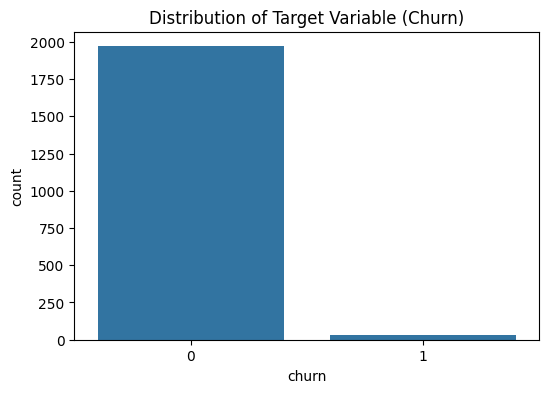

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# If the file is uploaded correctly, this will now work
df = pd.read_csv('customer_churn_nn.csv')

print(f"Dataset Shape: {df.shape}")
print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Statistical Summary ---")
display(df.describe())

# Target Variable Distribution
print("\n--- Churn Distribution ---")
print(df['churn'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='churn', data=df)
plt.title('Distribution of Target Variable (Churn)')

# SAVE TO RESULTS FOLDER (As per your assignment structure)
plt.savefig('results/target_distribution.png')
plt.show()

In [5]:
# --- TASK 2: DATA PREPROCESSING (Complete Version) ---
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Check if 'df' exists from Task 1, otherwise reload it
try:
    if 'df' not in locals():
        df = pd.read_csv('customer_churn_nn.csv')

    # 1. Drop identifier column
    df_prep = df.drop(columns=['customer_id'])

    # 2. Encoding categorical columns
    cat_cols = ['region', 'plan_type', 'contract_type', 'payment_method']
    df_prep = pd.get_dummies(df_prep, columns=cat_cols, drop_first=True)

    # 3. Separate features (X) and target variable (y)
    X = df_prep.drop(columns=['churn'])
    y = df_prep['churn']

    # 4. Scaling numerical features
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # 5. Splitting the dataset (80% Train, 20% Test)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    print("✅ Preprocessing Complete!")
    print(f"Training features shape: {X_train.shape}")

except FileNotFoundError:
    print("❌ Error: 'customer_churn_nn.csv' not found. Please upload the file to Colab first.")
except NameError as e:
    print(f"❌ Error: {e}. Make sure you ran the code in Task 1 first.")
except Exception as e:
    print(f"❌ An unexpected error occurred: {e}")

✅ Preprocessing Complete!
Training features shape: (1600, 24)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Starting Model Training...
Epoch 1/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.1111 - loss: 1.1133 - val_accuracy: 0.2438 - val_loss: 0.8826
Epoch 2/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4299 - loss: 0.7848 - val_accuracy: 0.6187 - val_loss: 0.6819
Epoch 3/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7944 - loss: 0.6228 - val_accuracy: 0.9375 - val_loss: 0.5505
Epoch 4/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9625 - loss: 0.4923 - val_accuracy: 0.9875 - val_loss: 0.4179
Epoch 5/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9819 - loss: 0.3493 - val_accuracy: 0.9937 - val_loss: 0.2538
Epoch 6/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9833 - loss: 0.2043 - val_accuracy: 0.9937 - val_loss: 0.1347
Epoch 7/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9833 - loss: 0.1321 - val_accuracy: 0.9937 - val_loss: 0.0884
Epoch 8/30
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9833 - loss: 0.1052 - val_

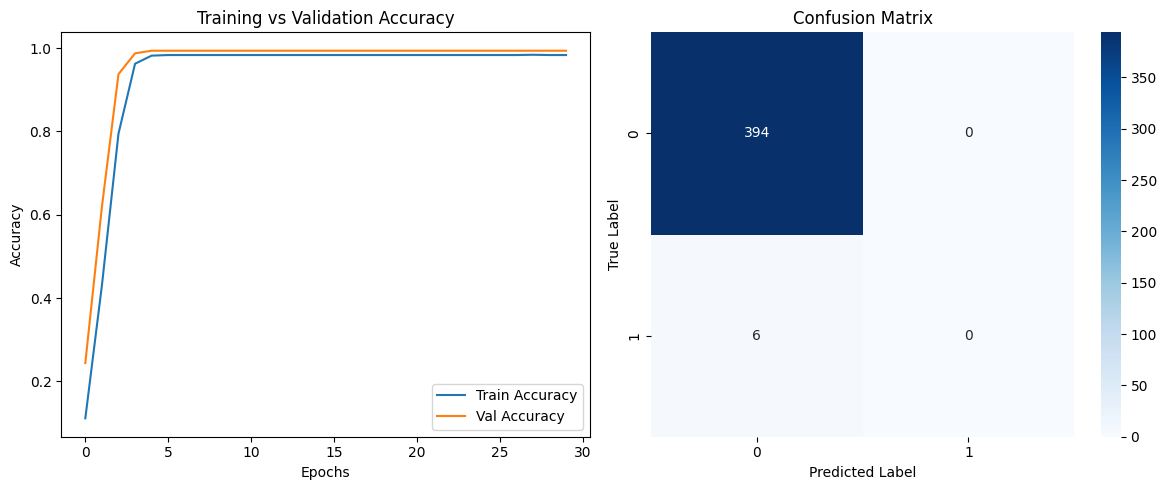


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       394
           1       0.00      0.00      0.00         6

    accuracy                           0.98       400
   macro avg       0.49      0.50      0.50       400
weighted avg       0.97      0.98      0.98       400



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [6]:
# --- TASK 3: MODEL BUILDING ---
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Define the architecture
model = Sequential([
    # Input layer + Hidden layer 1: 16 neurons, ReLU activation
    Dense(16, input_dim=X_train.shape[1], activation='relu'),
    # Hidden layer 2: 8 neurons, ReLU activation
    Dense(8, activation='relu'),
    # Output layer: 1 neuron, Sigmoid activation (for binary classification)
    Dense(1, activation='sigmoid')
])

# Compile the model
# Using Adam optimizer and Binary Crossentropy loss as it's a 0/1 classification task
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# --- TASK 4: TRAINING & EVALUATION ---
print("Starting Model Training...")
# Train the model for 30 epochs
history = model.fit(X_train, y_train, epochs=30, batch_size=32, validation_split=0.1, verbose=1)

# Evaluate on the test set
print("\n--- Final Test Evaluation ---")
loss, accuracy = model.evaluate(X_test, y_test)
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Create Evaluation Visuals
plt.figure(figsize=(12, 5))

# Plot 1: Accuracy Trend
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Confusion Matrix
plt.subplot(1, 2, 2)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

# Save the combined evaluation plot to the results folder
plt.tight_layout()
plt.savefig('results/evaluation_outputs.png')
plt.show()

# Print detailed metrics
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

In [7]:
# --- TASK 5: HYPERPARAMETER EXPERIMENTATION ---

def run_custom_experiment(name, num_layers, neurons, learning_rate):
    """Function to build and train a model based on specific parameters"""
    exp_model = Sequential()
    # Adding the first layer
    exp_model.add(Dense(neurons, input_dim=X_train.shape[1], activation='relu'))

    # Adding additional hidden layers if specified
    for _ in range(num_layers - 1):
        exp_model.add(Dense(neurons, activation='relu'))

    # Output layer
    exp_model.add(Dense(1, activation='sigmoid'))

    # Configure optimizer with specific learning rate
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    exp_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

    # Train for a shorter period for experimentation
    exp_model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

    # Get test accuracy
    _, acc = exp_model.evaluate(X_test, y_test, verbose=0)
    return {"Experiment": name, "Configuration": f"{num_layers} Layers, {neurons} Neurons, LR={learning_rate}", "Accuracy": round(acc, 4)}

# Define and run the experiments
experiment_list = []
experiment_list.append(run_custom_experiment("Exp 1: Deep Model", 3, 16, 0.01))
experiment_list.append(run_custom_experiment("Exp 2: Slow Learning", 1, 16, 0.0001))
experiment_list.append(run_custom_experiment("Exp 3: Wide Model", 1, 64, 0.01))

# Create the comparison table
comparison_df = pd.DataFrame(experiment_list)

# Save the table as a CSV in the results folder
comparison_df.to_csv('results/model_comparison_table.csv', index=False)

print("\n--- Hyperparameter Experimentation Results ---")
display(comparison_df)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Hyperparameter Experimentation Results ---


,Experiment,Configuration,Accuracy
0,Exp 1: Deep Model,"3 Layers, 16 Neurons, LR=0.01",0.965
1,Exp 2: Slow Learning,"1 Layers, 16 Neurons, LR=0.0001",0.885
2,Exp 3: Wide Model,"1 Layers, 64 Neurons, LR=0.01",0.985
